In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('fitness_log.csv')

print(df.shape)        # how many rows and columns
print(df.head(10))     # first 10 rows
print(df.info())       # data types — are numbers actually stored as numbers?
print(df.describe())   # min, max, mean, std for every column

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(df['hours_slept'], df['protein_grams'], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Hours Slept')
axes[0].set_ylabel('Protein (g)')
axes[0].set_title('Sleep vs Protein')

axes[1].scatter(df['workout_intensity'], df['protein_grams'], color='coral', alpha=0.7)
axes[1].set_xlabel('Workout Intensity')
axes[1].set_title('Intensity vs Protein')

axes[2].scatter(df['core_minutes'], df['protein_grams'], color='seagreen', alpha=0.7)
axes[2].set_xlabel('Core Minutes')
axes[2].set_title('Core Minutes vs Protein')

plt.tight_layout()
plt.show()

print(df[['hours_slept', 'workout_intensity', 'core_minutes', 'protein_grams']].corr())

In [ ]:
X = df[['hours_slept', 'workout_intensity', 'core_minutes']]
y = df['protein_grams']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% held back for testing
    random_state=42     # fixed seed so results are reproducible
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows:  {len(X_test)}")

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()    #remember the syntax
model.fit(X_train, y_train)

feature_names = ['hours_slept', 'workout_intensity', 'core_minutes']

print("Intercept (b):", round(model.intercept_, 2))
print("\nFeature weights:")
for name, coef in zip(feature_names, model.coef_):
    print(f"  {name}: {round(coef, 3)}")

Intercept (b): 21.54

Feature weights:
  hours_slept: 7.43
  workout_intensity: 5.032
  core_minutes: 1.376


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {round(mae, 2)} grams")
print(f"RMSE: {round(rmse, 2)} grams")
print(f"R²:   {round(r2, 3)}")

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.8, edgecolors='white', s=80)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min()) - 5
max_val = max(y_test.max(), y_pred.max()) + 5
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')

plt.xlabel('Actual Protein (g)')
plt.ylabel('Predicted Protein (g)')
plt.title('Actual vs Predicted Protein Intake')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
new_day = pd.DataFrame({
    'hours_slept':       [7.0],
    'workout_intensity': [8],
    'core_minutes':      [20]
})

predicted_protein = model.predict(new_day)
print(f"Predicted protein intake: {round(predicted_protein[0], 1)}g")

In [11]:
y_tree = df['next_day_readiness']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X, y_tree,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train_t, y_train_t)

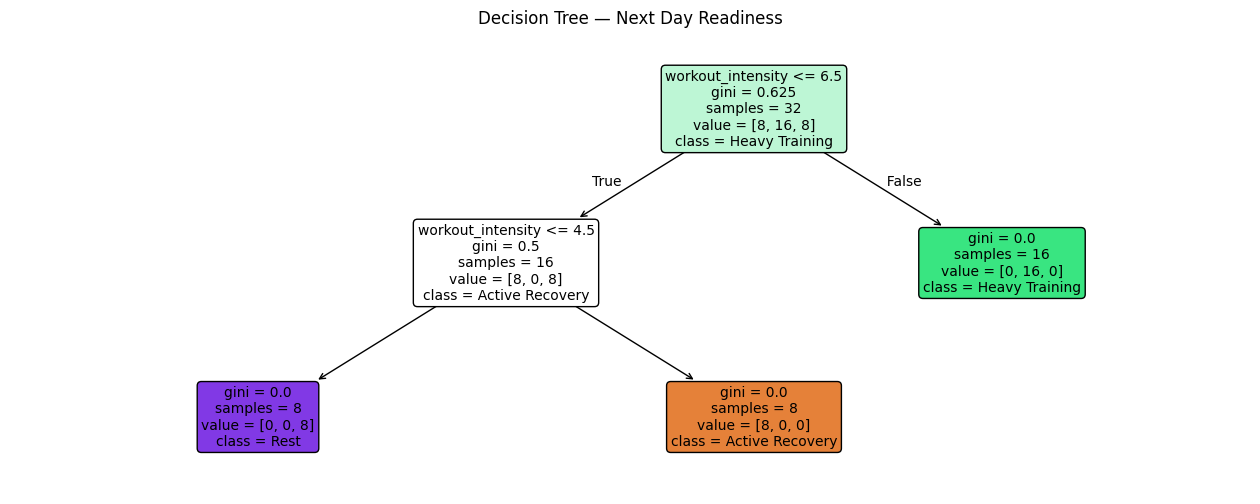

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
plot_tree(
    tree_model,
    feature_names=['hours_slept', 'workout_intensity', 'core_minutes'],
    class_names=['Active Recovery', 'Heavy Training', 'Rest'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree — Next Day Readiness")
plt.show()

In [15]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_tree = tree_model.predict(X_test_t)

print("Accuracy:", accuracy_score(y_test_t, y_pred_tree))
print("\nDetailed Report:")
print(classification_report(y_test_t, y_pred_tree))

Accuracy: 1.0

Detailed Report:
                 precision    recall  f1-score   support

Active Recovery       1.00      1.00      1.00         2
 Heavy Training       1.00      1.00      1.00         5
           Rest       1.00      1.00      1.00         1

       accuracy                           1.00         8
      macro avg       1.00      1.00      1.00         8
   weighted avg       1.00      1.00      1.00         8



In [16]:
importances = tree_model.feature_importances_
feature_names = ['hours_slept', 'workout_intensity', 'core_minutes']

for name, score in zip(feature_names, importances):
    print(f"{name}: {round(score, 3)}")

hours_slept: 0.0
workout_intensity: 1.0
core_minutes: 0.0


In [17]:
new_day = pd.DataFrame({
    'hours_slept':       [5.0],
    'workout_intensity': [3],
    'core_minutes':      [8]
})

prediction = tree_model.predict(new_day)
print("Predicted readiness:", prediction[0])

Predicted readiness: Rest
